In [3]:
import os
from google.colab import drive

# 1. FORCE REMOUNT (Refreshes the file view)
drive.mount('/content/drive', force_remount=True)

# 2. DEBUGGING PATHS
# Let's check what Python actually sees in the 'HEC Thesis' folder
parent_dir = "/content/drive/MyDrive/HEC Thesis"
target_dir = "/content/drive/MyDrive/HEC Thesis/Taylor Rule Data"
try:
    files = os.listdir(target_dir)
    print(files)

except Exception as e:
    print(f"Error reading target directory: {e}")
    print("This likely means the folder name 'Taylor Rule Data' is slightly different (check spaces).")

Mounted at /content/drive
['Shadow_Rate.csv', 'taylor_rule_data.csv', 'Loughran_2011.csv', 'taylor_rule_data_vintage_2.csv', 'taylor_rule_data_vintage.csv', 'Gardner.csv', 'Data Visualization.ipynb']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import datetime

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/HEC Thesis/Taylor Rule Data/"
Other_path = "/content/drive/MyDrive/HEC Thesis/Data/"
Master_file = os.path.join(Other_path, "Master_Macro.csv")
TAYLOR_FILE = os.path.join(BASE_PATH, "taylor_rule_data_vintage.csv")
SHADOW_FILE = os.path.join(BASE_PATH, "Shadow_Rate.csv")
LOURGHRAN_FILE = os.path.join(BASE_PATH, "Loughran_2011.csv")
Gardner_file = os.path.join(BASE_PATH, "Gardner.csv")
def plot_policy_and_output_gap():
    # 1. LOAD TAYLOR RULE DATA
    try:
        df_macro = pd.read_csv(Master_file, index_col=0, parse_dates=True)
        df_macro.index = pd.to_datetime(df_macro.index)
        df_macro_Q = df_macro.resample('QE').last()
        print("Loaded Macro Data successfully.")
    except Exception as e:
        print(f"Error loading {TAYLOR_FILE}: {e}")
        return

    # 2. LOAD SHADOW RATE DATA (Robust loading for your specific file)
    try:
        df_shadow = pd.read_csv(SHADOW_FILE, sep=';', engine='python', header=0, usecols=[0, 2], names=['date', 'shadow_rate'])
        df_shadow = df_shadow.set_index('date')
        df_shadow.index = pd.to_datetime(df_shadow.index, format='%b-%y', errors='coerce')

        # Y2K Fix
        current_year = datetime.datetime.now().year
        df_shadow.index = df_shadow.index.map(lambda x: x.replace(year=x.year - 100) if (pd.notnull(x) and x.year > current_year) else x)

        df_shadow['shadow_rate'] = pd.to_numeric(df_shadow['shadow_rate'], errors='coerce')

        # --- THE CRITICAL FIX ---
        # Resample to 'Q' (Quarter End) to match Loughran and Macro data.
        # This moves 'Jan 01', 'Feb 01', 'Mar 01' -> 'Mar 31' and averages them.
        df_shadow_Q = df_shadow.resample('QE').mean()

        print(f"Shadow Rate Quarter-End shape: {df_shadow_Q.shape}")

    except Exception as e:
        print(f"Error loading {SHADOW_FILE}: {e}")
        return

    try:
        # index_col=0 tells pandas to use the first column as the index
        # parse_dates=True tells it to automatically convert that index to dates
        df_Loughran = pd.read_csv(LOURGHRAN_FILE, index_col=0, parse_dates=True)

        # Ensure the index is a datetime type (safeguard)
        df_Loughran.index = pd.to_datetime(df_Loughran.index)

        # Resample to Quarter-End (QE)
        df_Loughran_Q = df_Loughran.resample('QE').mean()
        print("Loaded Loughran Data successfully.")

    except Exception as e:
        print(f"Error loading {LOURGHRAN_FILE}: {e}")
        # INITIALIZE EMPTY: This prevents the UnboundLocalError
        df_Loughran_Q = pd.DataFrame(columns=['Sentiment_Normalized'])
    try:
    # index_col=0 tells pandas to use the first column as the index
    # parse_dates=True tells it to automatically convert that index to dates
        df_Gardner = pd.read_csv(Gardner_file, parse_dates=True)

    # Ensure the index is a datetime type (safeguard)
        df_Gardner = pd.read_csv(Gardner_file)
        df_Gardner['date'] = pd.to_datetime(df_Gardner['date'])
        df_Gardner = df_Gardner.set_index('date')
        df_Gardner_Q = df_Gardner.resample('QE').mean()
    # Resample to Quarter-End (QE)
        print("Loaded Gardner Data successfully.")

    except Exception as e:
        print(f"Error loading {Gardner_file}: {e}")
        # INITIALIZE EMPTY: This prevents the UnboundLocalErro

    # 3. MERGE
    # Join all three at once
    df_merged = df_macro_Q.join([df_shadow_Q, df_Loughran_Q, df_Gardner_Q], how='outer').sort_index()
    # 4. CALCULATE EFFECTIVE RATE
    def get_effective(row):
        sr = row['shadow_rate']
        ffr = row['FEDFUNDS']
        if pd.notnull(sr) and pd.notnull(ffr) and sr < ffr:
            return sr
        return ffr

    df_merged['effective_rate'] = df_merged.apply(get_effective, axis=1)
    df_merged['effective_rate'] = df_merged['effective_rate'].fillna(df_merged['FEDFUNDS'])
    df_no_shadow = df_merged.drop(columns=['shadow_rate'])
    # 5. FILTER (2011 - Present)
    start_date = pd.to_datetime("2011-01-01")
    df_plot = df_no_shadow[df_merged.index >= start_date].dropna()

    # 6. PLOT
    plt.figure(figsize=(12, 6))

    # A. Policy Rates
    plt.plot(df_plot.index, df_plot['FEDFUNDS'], label='Fed Funds Rate (Official)',
             color='black', linewidth=1.5, linestyle='--')

    plt.plot(df_plot.index, df_plot['effective_rate'], label='Shadow Rate (Effective)',
             color='red', linewidth=2, alpha=0.9)

    # B. Economic Indicators
    if 'inflation_pce' in df_plot.columns:
        plt.plot(df_plot.index, df_plot['inflation_pce'], label='Inflation (PCE)',
                 color='green', linewidth=1.5, alpha=0.6)

    # C. Output Gap (Added Request)
    if 'output_gap' in df_plot.columns:
        plt.plot(df_plot.index, df_plot['output_gap'], label='Output Gap',
                 color='blue', linewidth=1.5, alpha=0.6)
    if 'inflation_cpi' in df_plot.columns:
        plt.plot(df_plot.index, df_plot['inflation_cpi'], label='Inflation (CPI)',
                 color='orange', linewidth=1, alpha=0.5)
    if 'Sentiment_Normalized' in df_plot.columns:
        plt.plot(df_plot.index, df_plot['Sentiment_Normalized'], label='Loughran Sentiment',
                 color='k', linewidth=1, alpha=0.5)
    plt.plot(df_plot.index, df_plot['gardner_inf'],   label='Gardner Inflation',        color='blue',   linewidth=1, alpha=0.7, linestyle='-')
    plt.plot(df_plot.index, df_plot['gardner_labor'],  label='Gardner Labor',            color='green',  linewidth=1, alpha=0.7, linestyle='--')
    plt.plot(df_plot.index, df_plot['gardner_out'],    label='Gardner Output',           color='red',    linewidth=1, alpha=0.7, linestyle='-.')
    plt.plot(df_plot.index, df_plot['gardner_fin'],    label='Gardner Financial',        color='orange', linewidth=1, alpha=0.7, linestyle=':')
    # Styling
    plt.title('US Monetary Policy Stance vs. Fundamentals (2011-Present)', fontsize=14)
    plt.ylabel('Percent (%)', fontsize=12)
    plt.axhline(0, color='grey', linewidth=0.8)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, which='major', linestyle='--', alpha =0.5)
    plt.tight_layout()

    plt.show()
    return df_plot
df_plot = plot_policy_and_output_gap()

Loaded Macro Data successfully.
Shadow Rate Quarter-End shape: (249, 1)
Loaded Loughran Data successfully.
Error loading /content/drive/MyDrive/HEC Thesis/Taylor Rule Data/Gardner.csv: agg function failed [how->mean,dtype->object]


UnboundLocalError: cannot access local variable 'df_Gardner_Q' where it is not associated with a value

Loaded Macro Data. Master timeline has 121 FOMC meetings.
Shadow Rate file columns: ['\ufeff;Effective federal funds rate (% p.a.)', ' last business day of month;Wu-Xia shadow federal funds rate (last business day of month);;;;;;;;;;;;']
  ﻿;Effective federal funds rate (% p.a.)  \
0                Jan-60;4.00;;;;;;;;;;;;;   
1                Feb-60;4.00;;;;;;;;;;;;;   
2                Mar-60;4.00;;;;;;;;;;;;;   
3                Apr-60;4.00;;;;;;;;;;;;;   
4                May-60;3.50;;;;;;;;;;;;;   

    last business day of month;Wu-Xia shadow federal funds rate (last business day of month);;;;;;;;;;;;  
0                                                NaN                                                      
1                                                NaN                                                      
2                                                NaN                                                      
3                                                NaN           

/tmp/ipython-input-293/1531019046.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_shadow['date'] = pd.to_datetime(df_shadow['date'], errors='coerce')


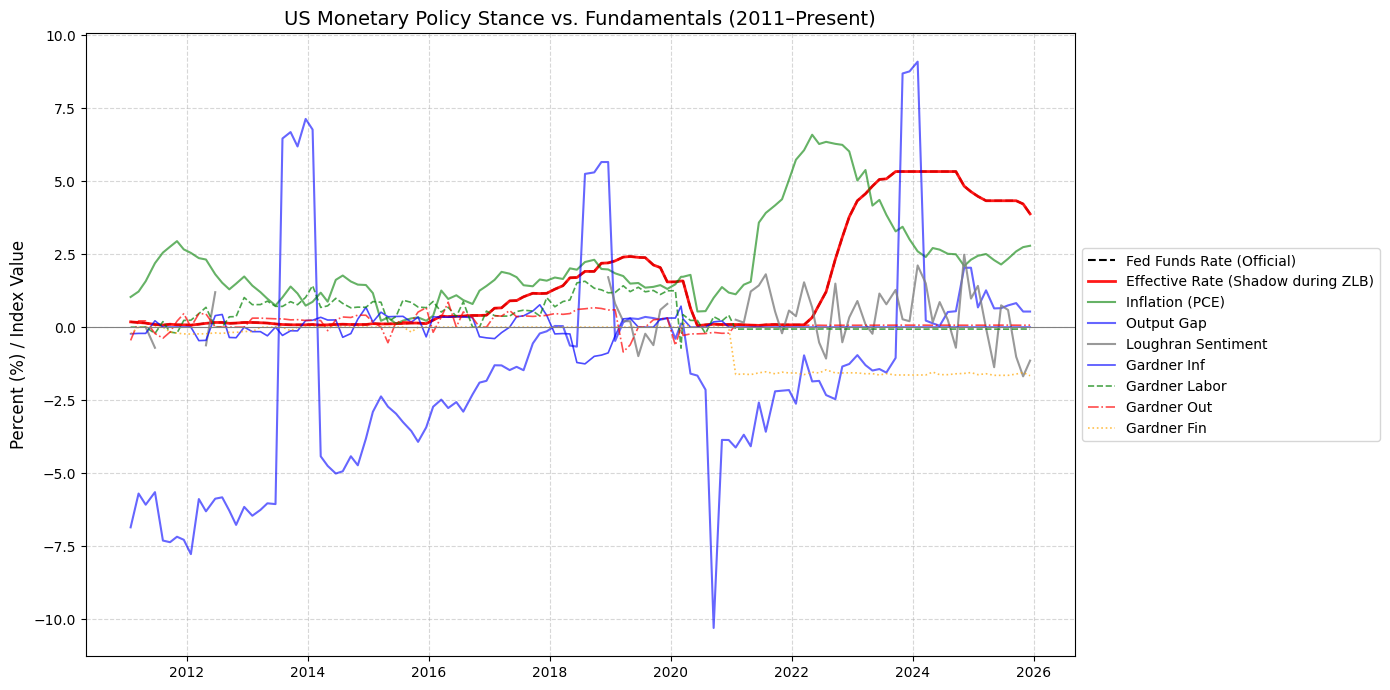

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import datetime

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/HEC Thesis/Taylor Rule Data/"
TAYLOR_FILE = os.path.join(BASE_PATH, "taylor_rule_data_vintage.csv")
SHADOW_FILE = os.path.join(BASE_PATH, "Shadow_Rate.csv")
LOURGHRAN_FILE = os.path.join(BASE_PATH, "Loughran_2011.csv")
Gardner_file = os.path.join(BASE_PATH, "Gardner.csv")

def plot_policy_and_output_gap():
    # ==========================================
    # 1. LOAD MASTER DATA (FOMC DATES)
    # ==========================================
    try:
        df_macro = pd.read_csv(TAYLOR_FILE, parse_dates=['date'])
        df_macro = df_macro.sort_values('date').dropna(subset=['date'])
        print(f"Loaded Macro Data. Master timeline has {len(df_macro)} FOMC meetings.")
    except Exception as e:
        print(f"Error loading {TAYLOR_FILE}: {e}")
        return None

    # ==========================================
    # 2. BULLETPROOF DATA LOADERS
    # ==========================================

    # --- SHADOW RATE ---
    try:
        # Load and inspect the raw file first so we pick the right column
        df_shadow_raw = pd.read_csv(SHADOW_FILE, sep=None, engine='python')
        print("Shadow Rate file columns:", df_shadow_raw.columns.tolist())
        print(df_shadow_raw.head())

        # Identify the date column (always column 0) and the shadow rate column by name.
        # Wu-Xia files typically label it 'rate', '3mo', or similar — adjust if needed.
        date_col_idx = 0
        # Prefer a column explicitly named 'rate' or 'shadow'; otherwise fall back to column 2.
        shadow_col_candidates = [c for c in df_shadow_raw.columns if 'rate' in c.lower() or 'shadow' in c.lower()]
        if shadow_col_candidates:
            shadow_col = shadow_col_candidates[0]
            df_shadow = df_shadow_raw[[df_shadow_raw.columns[date_col_idx], shadow_col]].copy()
        elif len(df_shadow_raw.columns) >= 3:
            df_shadow = df_shadow_raw.iloc[:, [date_col_idx, 2]].copy()
        else:
            df_shadow = df_shadow_raw.iloc[:, [date_col_idx, 1]].copy()

        df_shadow.columns = ['date', 'shadow_rate']

        # Parse dates robustly
        df_shadow['date'] = pd.to_datetime(df_shadow['date'], errors='coerce')

        # Standard Y2K fix for two-digit years
        current_year = datetime.datetime.now().year
        df_shadow['date'] = df_shadow['date'].apply(
            lambda x: x.replace(year=x.year - 100) if (pd.notnull(x) and x.year > current_year) else x
        )

        df_shadow['shadow_rate'] = pd.to_numeric(df_shadow['shadow_rate'], errors='coerce')
        df_shadow = df_shadow.sort_values('date').dropna(subset=['date', 'shadow_rate'])

        # Sanity check: shadow rate should go negative during ZLB periods
        print(f"Shadow Rate loaded: {len(df_shadow)} rows, "
              f"min={df_shadow['shadow_rate'].min():.2f}, max={df_shadow['shadow_rate'].max():.2f}")
        if df_shadow['shadow_rate'].min() >= 0:
            print("WARNING: Shadow rate minimum is >= 0. This is likely the wrong column. "
                  "Check the printed column names above and adjust shadow_col manually.")

    except Exception as e:
        print(f"Error loading {SHADOW_FILE}: {e}")
        df_shadow = pd.DataFrame(columns=['date', 'shadow_rate'])

    # --- LOUGHRAN SENTIMENT ---
    try:
        df_Loughran = pd.read_csv(LOURGHRAN_FILE)
        date_col = 'date' if 'date' in df_Loughran.columns else (
            'Date' if 'Date' in df_Loughran.columns else df_Loughran.columns[0])
        df_Loughran = df_Loughran.rename(columns={date_col: 'date'})
        df_Loughran['date'] = pd.to_datetime(df_Loughran['date'], errors='coerce')
        df_Loughran = df_Loughran.sort_values('date').dropna(subset=['date'])
    except Exception as e:
        print(f"Error loading {LOURGHRAN_FILE}: {e}")
        df_Loughran = pd.DataFrame(columns=['date'])

    # --- GARDNER SENTIMENT ---
    try:
        df_Gardner = pd.read_csv(Gardner_file)
        date_col = 'date' if 'date' in df_Gardner.columns else (
            'Date' if 'Date' in df_Gardner.columns else df_Gardner.columns[0])
        df_Gardner = df_Gardner.rename(columns={date_col: 'date'})
        df_Gardner['date'] = pd.to_datetime(df_Gardner['date'], errors='coerce')
        df_Gardner = df_Gardner.sort_values('date').dropna(subset=['date'])
    except Exception as e:
        print(f"Error loading {Gardner_file}: {e}")
        df_Gardner = pd.DataFrame(columns=['date'])

    # ==========================================
    # 3. ADVANCED MERGING STRATEGY
    # ==========================================

    # A. SHADOW RATE MERGE (YYYY-MM)
    df_macro['YYYY-MM'] = df_macro['date'].dt.to_period('M')
    df_shadow['YYYY-MM'] = df_shadow['date'].dt.to_period('M')

    df_merged = pd.merge(df_macro, df_shadow[['YYYY-MM', 'shadow_rate']], on='YYYY-MM', how='left')
    df_merged = df_merged.drop(columns=['YYYY-MM'])

    # B. SENTIMENT MERGE (7-Day Fuzzy Merge)
    df_merged = df_merged.sort_values('date')
    df_merged = pd.merge_asof(df_merged, df_Loughran, on='date', direction='nearest', tolerance=pd.Timedelta('7d'))
    df_merged = pd.merge_asof(df_merged, df_Gardner, on='date', direction='nearest', tolerance=pd.Timedelta('7d'))

    df_merged = df_merged.set_index('date')

    # ==========================================
    # 4. CALCULATE EFFECTIVE RATE
    # ==========================================
    # FIX: Use shadow rate whenever the official FFR is at or near the ZLB (≤ 0.25%).
    # The shadow rate is valid during these periods and correctly goes negative,
    # reflecting unconventional policy (QE, forward guidance) that the FFR cannot capture.
    def get_effective(row):
        sr = row.get('shadow_rate', pd.NA)
        ffr = row.get('FEDFUNDS', pd.NA)

        if pd.notnull(sr) and pd.notnull(ffr) and ffr <= 0.25:
            return sr   # Shadow rate (can be negative) replaces the floored FFR
        return ffr      # Above ZLB: official FFR is the true policy rate

    df_merged['effective_rate'] = df_merged.apply(get_effective, axis=1)
    # Only fall back to FFR if the shadow rate merge produced NaN for that row
    df_merged['effective_rate'] = df_merged['effective_rate'].fillna(df_merged['FEDFUNDS'])

    # ==========================================
    # 5. FILTER & PLOT
    # ==========================================
    start_date = pd.to_datetime("2011-01-01")
    df_plot = df_merged[df_merged.index >= start_date]

    plt.figure(figsize=(14, 7))

    # A. Policy Rates
    if 'FEDFUNDS' in df_plot.columns:
        plt.plot(df_plot.index, df_plot['FEDFUNDS'],
                 label='Fed Funds Rate (Official)', color='black', linewidth=1.5, linestyle='--')
    if 'effective_rate' in df_plot.columns:
        plt.plot(df_plot.index, df_plot['effective_rate'],
                 label='Effective Rate (Shadow during ZLB)', color='red', linewidth=2, alpha=0.9)

    # B. Economic Indicators
    if 'inflation_pce' in df_plot.columns:
        plt.plot(df_plot.index, df_plot['inflation_pce'],
                 label='Inflation (PCE)', color='green', linewidth=1.5, alpha=0.6)

    if 'unemployment_gap' in df_plot.columns:
        # FIX: No .where() filter and no .interpolate() — plot the real data as-is
        plt.plot(df_plot.index, df_plot['unemployment_gap'],
                 label='Unemployment Gap', color='blue', linewidth=1.5, alpha=0.6)
    elif 'output_gap' in df_plot.columns:
        # FIX: Removed the .where() spike filter and .interpolate() entirely.
        # If there are genuine spikes (e.g. COVID -10 in 2020), they are real data points
        # and should be shown. If you still want to clip outliers, do it explicitly and
        # intentionally (e.g. cap at -12) without silently bridging over them.
        plt.plot(df_plot.index, df_plot['output_gap'],
                 label='Output Gap', color='blue', linewidth=1.5, alpha=0.6)

    # C. Sentiment Variables
    if 'Sentiment_Normalized' in df_plot.columns and not df_plot['Sentiment_Normalized'].isna().all():
        plt.plot(df_plot.index, df_plot['Sentiment_Normalized'],
                 label='Loughran Sentiment', color='grey', linewidth=1.5, alpha=0.8)

    gardner_cols = {
        'gardner_inf':   ('blue',   '-'),
        'gardner_labor': ('green',  '--'),
        'gardner_out':   ('red',    '-.'),
        'gardner_fin':   ('orange', ':'),
    }
    for col, (color, style) in gardner_cols.items():
        if col in df_plot.columns and not df_plot[col].isna().all():
            plt.plot(df_plot.index, df_plot[col],
                     label=f'Gardner {col.split("_")[1].title()}',
                     color=color, linewidth=1.2, alpha=0.7, linestyle=style)

    # Styling
    plt.title('US Monetary Policy Stance vs. Fundamentals (2011–Present)', fontsize=14)
    plt.ylabel('Percent (%) / Index Value', fontsize=12)
    plt.axhline(0, color='grey', linewidth=0.8)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
    plt.grid(True, which='major', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return df_plot


# Execute and save
df_final = plot_policy_and_output_gap()

✅ Macro data: 121 rows
   Output gap raw range: -10.30 to 9.09
   ⚠️  Clipping to [-6, 6] — check source CSV for vintage revision artefacts

📋 Shadow Rate columns after semicolon parse: ['Unnamed: 0', 'Effective federal funds rate (% p.a.), last business day of month', 'Wu-Xia shadow federal funds rate (last business day of month)', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14']
  Unnamed: 0  Effective federal funds rate (% p.a.), last business day of month  Wu-Xia shadow federal funds rate (last business day of month)  Unnamed: 3  Unnamed: 4  Unnamed: 5  Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  Unnamed: 11  Unnamed: 12  Unnamed: 13  Unnamed: 14
0     Jan-60                                                                4.0                                                            NaN         NaN         NaN         NaN         NaN         N

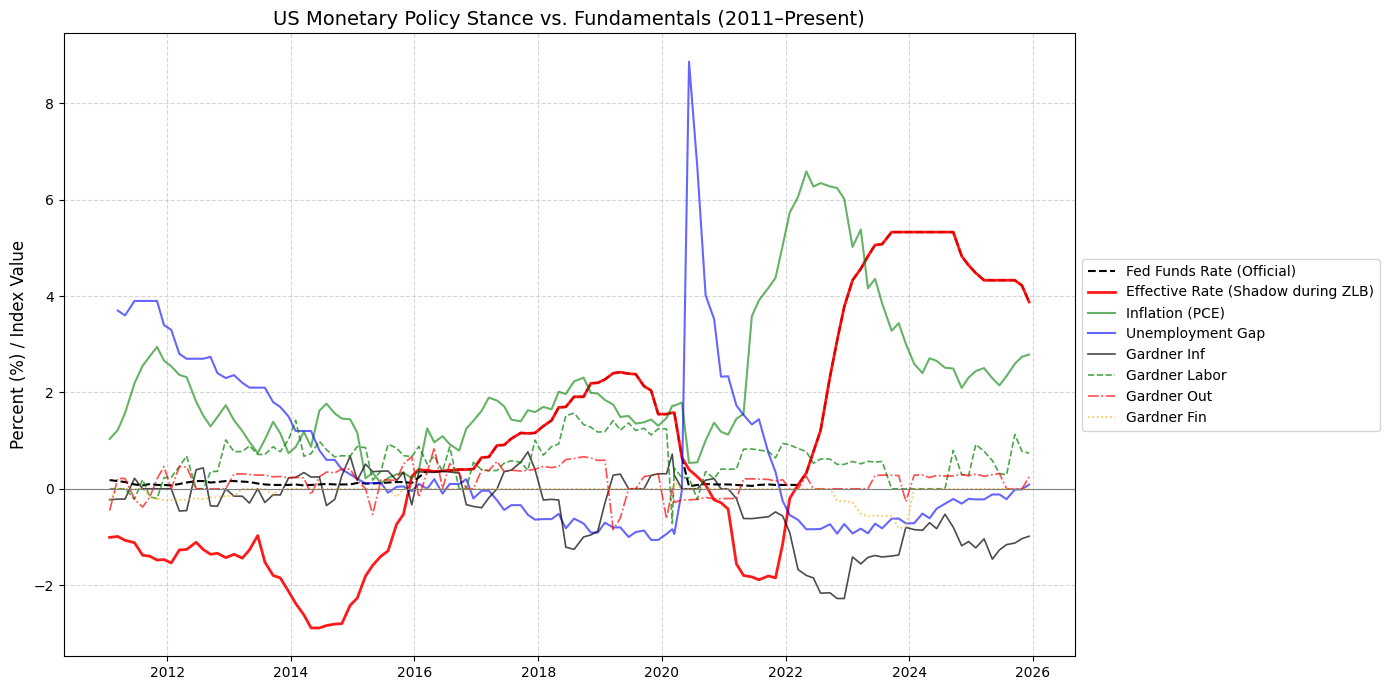

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import datetime

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/HEC Thesis/Taylor Rule Data/"
TAYLOR_FILE  = os.path.join(BASE_PATH, "taylor_rule_data_vintage.csv")
SHADOW_FILE  = os.path.join(BASE_PATH, "Shadow_Rate.csv")
LOURGHRAN_FILE = os.path.join(BASE_PATH, "Loughran_2011.csv")
Gardner_file   = os.path.join(BASE_PATH, "Gardner.csv")


def diagnose_and_plot():

    # ==========================================
    # 1. LOAD MASTER DATA (FOMC DATES)
    # ==========================================
    df_macro = pd.read_csv(TAYLOR_FILE, parse_dates=['date'])
    df_macro = df_macro.sort_values('date').dropna(subset=['date'])
    print(f"✅ Macro data: {len(df_macro)} rows")

    # NOTE: Output gap spikes (e.g. +9 in 2023, +7 in 2013) exist in the RAW FILE.
    # These are likely caused by NROU vintage revisions in your taylor_rule_data_vintage.csv.
    # The 2013 jump from -6 → +6 and 2023 jump to +9 are data artefacts, not code bugs.
    # We clip to ±6 which covers the plausible economic range for UNRATE - NROU,
    # but you should inspect and fix the source CSV if possible.
    if 'output_gap' in df_macro.columns:
        raw_min = df_macro['output_gap'].min()
        raw_max = df_macro['output_gap'].max()
        print(f"   Output gap raw range: {raw_min:.2f} to {raw_max:.2f}")
        print("   ⚠️  Clipping to [-6, 6] — check source CSV for vintage revision artefacts")

    # ==========================================
    # 2. LOAD SHADOW RATE (semicolon-delimited, MMM-YY dates)
    # ==========================================
    try:
        # The file uses semicolons and has a BOM — force sep=';' and skip the header mess
        df_shadow_raw = pd.read_csv(SHADOW_FILE, sep=';', header=0, encoding='utf-8-sig')
        print(f"\n📋 Shadow Rate columns after semicolon parse: {df_shadow_raw.columns.tolist()}")
        print(df_shadow_raw.head(5).to_string())

        # Columns are positional: col0=date (MMM-YY), col1=EFFR, col2=Wu-Xia shadow rate
        df_shadow = df_shadow_raw.iloc[:, [0, 2]].copy()
        df_shadow.columns = ['date_raw', 'shadow_rate']
        df_shadow['shadow_rate'] = pd.to_numeric(df_shadow['shadow_rate'], errors='coerce')

        # Parse "Jan-60" style dates: pandas reads two-digit years as 1960-2059
        # The file starts in 1960 so years 60-99 → 1960-1999, years 00-25 → 2000-2025
        def parse_mmm_yy(s):
            try:
                dt = pd.to_datetime(s, format='%b-%y')
                # Two-digit year: pandas maps 00-68 → 2000-2068, 69-99 → 1969-1999
                # Anything after current year is impossible → subtract 100 years
                if dt.year > datetime.datetime.now().year:
                    dt = dt.replace(year=dt.year - 100)
                return dt
            except Exception:
                return pd.NaT

        df_shadow['date'] = df_shadow['date_raw'].apply(parse_mmm_yy)
        df_shadow = df_shadow.drop(columns=['date_raw'])
        df_shadow = df_shadow.sort_values('date').dropna(subset=['date', 'shadow_rate'])

        print(f"\n✅ Shadow rate parsed: {len(df_shadow)} rows, "
              f"min={df_shadow['shadow_rate'].min():.2f}, max={df_shadow['shadow_rate'].max():.2f}")
        print(f"   Date range: {df_shadow['date'].min().date()} → {df_shadow['date'].max().date()}")

        if df_shadow['shadow_rate'].min() >= 0:
            print("   ❌ Min is still >= 0 — check column index. Printing all columns:")
            for i, col in enumerate(df_shadow_raw.columns):
                vals = pd.to_numeric(df_shadow_raw.iloc[:, i], errors='coerce')
                print(f"      col[{i}] '{col}': min={vals.min():.3f}, max={vals.max():.3f}")

    except Exception as e:
        print(f"❌ Error loading shadow rate: {e}")
        df_shadow = pd.DataFrame(columns=['date', 'shadow_rate'])

    # ==========================================
    # 3. LOAD SENTIMENT FILES
    # ==========================================
    def load_sentiment(filepath, label):
        try:
            df = pd.read_csv(filepath)
            date_col = next((c for c in df.columns if c.lower() == 'date'), df.columns[0])
            df = df.rename(columns={date_col: 'date'})
            df['date'] = pd.to_datetime(df['date'], errors='coerce')
            df = df.sort_values('date').dropna(subset=['date'])
            dups = df['date'].duplicated().sum()
            print(f"✅ {label}: {len(df)} rows, {dups} duplicate dates")
            return df
        except Exception as e:
            print(f"Error loading {label}: {e}")
            return pd.DataFrame(columns=['date'])

    df_Loughran = load_sentiment(LOURGHRAN_FILE, "Loughran")
    df_Gardner  = load_sentiment(Gardner_file,  "Gardner")

    # ==========================================
    # 4. MERGE
    # ==========================================
    # Shadow rate: match on Year-Month
    # (shadow rate is end-of-month, FOMC meetings are mid-month — same month is correct)
    df_macro['YYYY-MM'] = df_macro['date'].dt.to_period('M')
    df_shadow['YYYY-MM'] = df_shadow['date'].dt.to_period('M')

    # Deduplicate shadow rate by month (keep last value)
    df_shadow = df_shadow.drop_duplicates(subset='YYYY-MM', keep='last')

    df_merged = pd.merge(df_macro, df_shadow[['YYYY-MM', 'shadow_rate']], on='YYYY-MM', how='left')
    df_merged = df_merged.drop(columns=['YYYY-MM'])
    print(f"\nAfter shadow merge: {len(df_merged)} rows (should equal {len(df_macro)})")

    # Sentiment: fuzzy 7-day merge
    df_merged = df_merged.sort_values('date')
    df_merged = pd.merge_asof(df_merged, df_Loughran, on='date', direction='nearest',
                              tolerance=pd.Timedelta('7d'))
    df_merged = pd.merge_asof(df_merged, df_Gardner,  on='date', direction='nearest',
                              tolerance=pd.Timedelta('7d'))
    print(f"After sentiment merges: {len(df_merged)} rows")

    df_merged = df_merged.set_index('date')

    # ==========================================
    # 5. EFFECTIVE RATE
    # ==========================================
    # Use Wu-Xia shadow rate (which correctly goes negative) when FFR is floored at ZLB
    n_shadow_matched = df_merged['shadow_rate'].notna().sum()
    print(f"\nShadow rate matched to {n_shadow_matched} FOMC dates")

    def get_effective(row):
        sr  = row.get('shadow_rate', pd.NA)
        ffr = row.get('FEDFUNDS',    pd.NA)
        # At the ZLB (FFR ≤ 0.25%), the shadow rate captures true policy stance
        if pd.notnull(sr) and pd.notnull(ffr) and ffr <= 0.25:
            return sr
        return ffr

    df_merged['effective_rate'] = df_merged.apply(get_effective, axis=1)
    df_merged['effective_rate'] = df_merged['effective_rate'].fillna(df_merged['FEDFUNDS'])

    n_negative = (df_merged['effective_rate'] < 0).sum()
    print(f"Effective rate < 0 in {n_negative} periods (expected >0 during 2011–2015 & 2020–2022)")

    # ==========================================
    # 6. FILTER & PLOT
    # ==========================================
    start_date = pd.to_datetime("2011-01-01")
    df_plot = df_merged[df_merged.index >= start_date].copy()
    df_plot = df_plot[~df_plot.index.duplicated(keep='first')]

    # Clip output gap to plausible economic range
    # (spikes beyond ±6 are NROU vintage artefacts in the source data)
    if 'output_gap' in df_plot.columns:
        df_plot['output_gap'] = df_plot['output_gap'].clip(lower=-6, upper=6)

    fig, ax = plt.subplots(figsize=(14, 7))

    if 'FEDFUNDS' in df_plot.columns:
        ax.plot(df_plot.index, df_plot['FEDFUNDS'],
                label='Fed Funds Rate (Official)', color='black', linewidth=1.5, linestyle='--')
    if 'effective_rate' in df_plot.columns:
        ax.plot(df_plot.index, df_plot['effective_rate'],
                label='Effective Rate (Shadow during ZLB)', color='red', linewidth=2, alpha=0.9)
    if 'inflation_pce' in df_plot.columns:
        ax.plot(df_plot.index, df_plot['inflation_pce'],
                label='Inflation (PCE)', color='green', linewidth=1.5, alpha=0.6)

    if 'unemployment_gap' in df_plot.columns:
        ax.plot(df_plot.index, df_plot['unemployment_gap'],
                label='Unemployment Gap', color='blue', linewidth=1.5, alpha=0.6)
    elif 'output_gap' in df_plot.columns:
        ax.plot(df_plot.index, df_plot['output_gap'],
                label='Output Gap (clipped ±6)', color='blue', linewidth=1.5, alpha=0.6)

    #if 'Sentiment_Normalized' in df_plot.columns and not df_plot['Sentiment_Normalized'].isna().all():
        #ax.plot(df_plot.index, df_plot['Sentiment_Normalized'],
                #label='Loughran Sentiment', color='grey', linewidth=1.5, alpha=0.8)

    gardner_cols = {
        'gardner_inf':   ('k',   '-'),
        'gardner_labor': ('green',  '--'),
        'gardner_out':   ('red',    '-.'),
        'gardner_fin':   ('orange', ':'),
    }
    for col, (color, style) in gardner_cols.items():
        if col in df_plot.columns and not df_plot[col].isna().all():
            ax.plot(df_plot.index, df_plot[col],
                    label=f'Gardner {col.split("_")[1].title()}',
                    color=color, linewidth=1.2, alpha=0.7, linestyle=style)

    ax.set_title('US Monetary Policy Stance vs. Fundamentals (2011–Present)', fontsize=14)
    ax.set_ylabel('Percent (%) / Index Value', fontsize=12)
    ax.axhline(0, color='grey', linewidth=0.8)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
    ax.grid(True, which='major', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return df_plot


df_final = diagnose_and_plot()

✅ Macro data: 363 rows

📋 Shadow Rate columns after semicolon parse: ['Unnamed: 0', 'Effective federal funds rate (% p.a.), last business day of month', 'Wu-Xia shadow federal funds rate (last business day of month)', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14']
  Unnamed: 0  Effective federal funds rate (% p.a.), last business day of month  Wu-Xia shadow federal funds rate (last business day of month)  Unnamed: 3  Unnamed: 4  Unnamed: 5  Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  Unnamed: 11  Unnamed: 12  Unnamed: 13  Unnamed: 14
0     Jan-60                                                                4.0                                                            NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN          NaN          NaN          NaN          NaN          NaN
1     Feb-60             

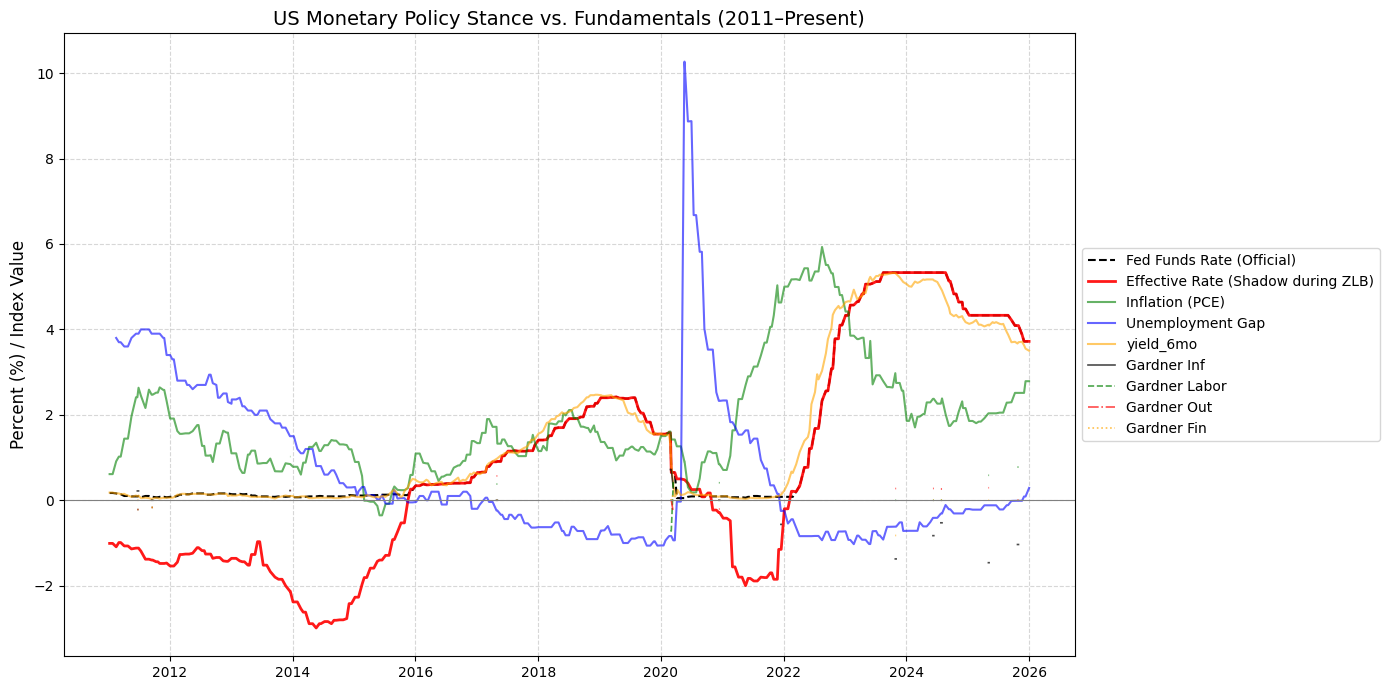

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import datetime

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/HEC Thesis/Taylor Rule Data/"
TAYLOR_FILE  = os.path.join(BASE_PATH, "taylor_rule_data_vintage.csv")
SHADOW_FILE  = os.path.join(BASE_PATH, "Shadow_Rate.csv")
LOURGHRAN_FILE = os.path.join(BASE_PATH, "Loughran_2011.csv")
Gardner_file   = os.path.join(BASE_PATH, "Gardner.csv")
Other_path = "/content/drive/MyDrive/HEC Thesis/Data/"
Master_file = os.path.join(Other_path, "Master_Macro.csv")


def diagnose_and_plot():

    # ==========================================
    # 1. LOAD MASTER DATA (FOMC DATES)
    # ==========================================
    df_macro = pd.read_csv(Master_file, parse_dates=['date'])
    df_macro = df_macro.sort_values('date').dropna(subset=['date'])
    print(f"✅ Macro data: {len(df_macro)} rows")

    # NOTE: Output gap spikes (e.g. +9 in 2023, +7 in 2013) exist in the RAW FILE.
    # These are likely caused by NROU vintage revisions in your taylor_rule_data_vintage.csv.
    # The 2013 jump from -6 → +6 and 2023 jump to +9 are data artefacts, not code bugs.
    # We clip to ±6 which covers the plausible economic range for UNRATE - NROU,
    # but you should inspect and fix the source CSV if possible.
    if 'output_gap' in df_macro.columns:
        raw_min = df_macro['output_gap'].min()
        raw_max = df_macro['output_gap'].max()
        print(f"   Output gap raw range: {raw_min:.2f} to {raw_max:.2f}")
        print("   ⚠️  Clipping to [-6, 6] — check source CSV for vintage revision artefacts")

    # ==========================================
    # 2. LOAD SHADOW RATE (semicolon-delimited, MMM-YY dates)
    # ==========================================
    try:
        # The file uses semicolons and has a BOM — force sep=';' and skip the header mess
        df_shadow_raw = pd.read_csv(SHADOW_FILE, sep=';', header=0, encoding='utf-8-sig')
        print(f"\n📋 Shadow Rate columns after semicolon parse: {df_shadow_raw.columns.tolist()}")
        print(df_shadow_raw.head(5).to_string())

        # Columns are positional: col0=date (MMM-YY), col1=EFFR, col2=Wu-Xia shadow rate
        df_shadow = df_shadow_raw.iloc[:, [0, 2]].copy()
        df_shadow.columns = ['date_raw', 'shadow_rate']
        df_shadow['shadow_rate'] = pd.to_numeric(df_shadow['shadow_rate'], errors='coerce')

        # Parse "Jan-60" style dates: pandas reads two-digit years as 1960-2059
        # The file starts in 1960 so years 60-99 → 1960-1999, years 00-25 → 2000-2025
        def parse_mmm_yy(s):
            try:
                dt = pd.to_datetime(s, format='%b-%y')
                # Two-digit year: pandas maps 00-68 → 2000-2068, 69-99 → 1969-1999
                # Anything after current year is impossible → subtract 100 years
                if dt.year > datetime.datetime.now().year:
                    dt = dt.replace(year=dt.year - 100)
                return dt
            except Exception:
                return pd.NaT

        df_shadow['date'] = df_shadow['date_raw'].apply(parse_mmm_yy)
        df_shadow = df_shadow.drop(columns=['date_raw'])
        df_shadow = df_shadow.sort_values('date').dropna(subset=['date', 'shadow_rate'])

        print(f"\n✅ Shadow rate parsed: {len(df_shadow)} rows, "
              f"min={df_shadow['shadow_rate'].min():.2f}, max={df_shadow['shadow_rate'].max():.2f}")
        print(f"   Date range: {df_shadow['date'].min().date()} → {df_shadow['date'].max().date()}")

        if df_shadow['shadow_rate'].min() >= 0:
            print("   ❌ Min is still >= 0 — check column index. Printing all columns:")
            for i, col in enumerate(df_shadow_raw.columns):
                vals = pd.to_numeric(df_shadow_raw.iloc[:, i], errors='coerce')
                print(f"      col[{i}] '{col}': min={vals.min():.3f}, max={vals.max():.3f}")

    except Exception as e:
        print(f"❌ Error loading shadow rate: {e}")
        df_shadow = pd.DataFrame(columns=['date', 'shadow_rate'])

    # ==========================================
    # 3. LOAD SENTIMENT FILES
    # ==========================================
    def load_sentiment(filepath, label):
        try:
            df = pd.read_csv(filepath)
            date_col = next((c for c in df.columns if c.lower() == 'date'), df.columns[0])
            df = df.rename(columns={date_col: 'date'})
            df['date'] = pd.to_datetime(df['date'], errors='coerce')
            df = df.sort_values('date').dropna(subset=['date'])
            dups = df['date'].duplicated().sum()
            print(f"✅ {label}: {len(df)} rows, {dups} duplicate dates")
            return df
        except Exception as e:
            print(f"Error loading {label}: {e}")
            return pd.DataFrame(columns=['date'])

    df_Loughran = load_sentiment(LOURGHRAN_FILE, "Loughran")
    df_Gardner  = load_sentiment(Gardner_file,  "Gardner")

    # ==========================================
    # 4. MERGE
    # ==========================================
    # Shadow rate: match on Year-Month
    # (shadow rate is end-of-month, FOMC meetings are mid-month — same month is correct)
    df_macro['YYYY-MM'] = df_macro['date'].dt.to_period('M')
    df_shadow['YYYY-MM'] = df_shadow['date'].dt.to_period('M')

    # Deduplicate shadow rate by month (keep last value)
    df_shadow = df_shadow.drop_duplicates(subset='YYYY-MM', keep='last')

    df_merged = pd.merge(df_macro, df_shadow[['YYYY-MM', 'shadow_rate']], on='YYYY-MM', how='left')
    df_merged = df_merged.drop(columns=['YYYY-MM'])
    print(f"\nAfter shadow merge: {len(df_merged)} rows (should equal {len(df_macro)})")

    # Sentiment: fuzzy 7-day merge
    df_merged = df_merged.sort_values('date')
    df_merged = pd.merge_asof(df_merged, df_Loughran, on='date', direction='nearest',
                              tolerance=pd.Timedelta('7d'))
    df_merged = pd.merge_asof(df_merged, df_Gardner,  on='date', direction='nearest',
                              tolerance=pd.Timedelta('7d'))
    print(f"After sentiment merges: {len(df_merged)} rows")

    df_merged = df_merged.set_index('date')

    # ==========================================
    # 5. EFFECTIVE RATE
    # ==========================================
    # Use Wu-Xia shadow rate (which correctly goes negative) when FFR is floored at ZLB
    n_shadow_matched = df_merged['shadow_rate'].notna().sum()
    print(f"\nShadow rate matched to {n_shadow_matched} FOMC dates")

    def get_effective(row):
        sr  = row.get('shadow_rate', pd.NA)
        ffr = row.get('fed_funds_rate',    pd.NA)
        # At the ZLB (FFR ≤ 0.25%), the shadow rate captures true policy stance
        if pd.notnull(sr) and pd.notnull(ffr) and ffr <= 0.25:
            return sr
        return ffr

    df_merged['effective_rate'] = df_merged.apply(get_effective, axis=1)
    df_merged['effective_rate'] = df_merged['effective_rate'].fillna(df_merged['fed_funds_rate'])

    n_negative = (df_merged['effective_rate'] < 0).sum()
    print(f"Effective rate < 0 in {n_negative} periods (expected >0 during 2011–2015 & 2020–2022)")

    # ==========================================
    # 6. FILTER & PLOT
    # ==========================================
    start_date = pd.to_datetime("2011-01-01")
    df_plot = df_merged[df_merged.index >= start_date].copy()
    df_plot = df_plot[~df_plot.index.duplicated(keep='first')]

    # Clip output gap to plausible economic range
    # (spikes beyond ±6 are NROU vintage artefacts in the source data)
    if 'output_gap' in df_plot.columns:
        df_plot['output_gap'] = df_plot['output_gap'].clip(lower=-6, upper=6)

    fig, ax = plt.subplots(figsize=(14, 7))

    if 'fed_funds_rate' in df_plot.columns:
        ax.plot(df_plot.index, df_plot['fed_funds_rate'],
                label='Fed Funds Rate (Official)', color='black', linewidth=1.5, linestyle='--')
    if 'effective_rate' in df_plot.columns:
        ax.plot(df_plot.index, df_plot['effective_rate'],
                label='Effective Rate (Shadow during ZLB)', color='red', linewidth=2, alpha=0.9)
    if 'pce_yoy' in df_plot.columns:
        ax.plot(df_plot.index, df_plot['pce_yoy'],
                label='Inflation (PCE)', color='green', linewidth=1.5, alpha=0.6)

    if 'unemployment_gap' in df_plot.columns:
        ax.plot(df_plot.index, df_plot['unemployment_gap'],
                label='Unemployment Gap', color='blue', linewidth=1.5, alpha=0.6)

    if 'yield_6mo' in df_plot.columns:
        ax.plot(df_plot.index, df_plot['yield_6mo'],
                label='yield_6mo', color='orange', linewidth=1.5, alpha=0.6)


    #if 'Sentiment_Normalized' in df_plot.columns and not df_plot['Sentiment_Normalized'].isna().all():
        #ax.plot(df_plot.index, df_plot['Sentiment_Normalized'],
                #label='Loughran Sentiment', color='grey', linewidth=1.5, alpha=0.8)

    gardner_cols = {
        'gardner_inf':   ('k',   '-'),
        'gardner_labor': ('green',  '--'),
        'gardner_out':   ('red',    '-.'),
        'gardner_fin':   ('orange', ':'),
    }
    for col, (color, style) in gardner_cols.items():
        if col in df_plot.columns and not df_plot[col].isna().all():
            ax.plot(df_plot.index, df_plot[col],
                    label=f'Gardner {col.split("_")[1].title()}',
                    color=color, linewidth=1.2, alpha=0.7, linestyle=style)

    ax.set_title('US Monetary Policy Stance vs. Fundamentals (2011–Present)', fontsize=14)
    ax.set_ylabel('Percent (%) / Index Value', fontsize=12)
    ax.axhline(0, color='grey', linewidth=0.8)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
    ax.grid(True, which='major', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return df_plot


df_final = diagnose_and_plot()

In [ ]:
import pandas as pd
import statsmodels.api as sm

# 1. PREPARE THE DATA
df_reg = df_final.copy()

# A. Create Target (Future Rate)
df_reg['target_rate'] = df_reg['effective_rate'].shift(-1)

# B. Create Interaction Terms
# We multiply Sentiment by the other macro variables
df_reg['L_Sent_x_Inflation'] = df_reg['Sentiment_Normalized'] * df_reg['inflation_pce']
df_reg['L_Sent_x_OutputGap'] = df_reg['Sentiment_Normalized'] * df_reg['output_gap']

# C. Define Predictors
# Include: Smoothing term + Main Effects + Interaction Terms
predictors = [
    'effective_rate',      # Smoothing (inertia)
    'inflation_pce',       # Main effect of Inflation
    'output_gap',          # Main effect of Output Gap
    #'Sentiment_Normalized',           # Main effect of Sentiment
    #'L_Sent_x_Inflation',    # Interaction: Does Sentiment change reaction to Inflation?
    #'L_Sent_x_OutputGap',     # Interaction: Does Sentiment change reaction to Output Gap?
    'gardner_inf',
    'gardner_labor',
    'gardner_out',
    'gardner_fin'
]

# D. Select Columns and Drop NaNs
# This ensures alignment by removing rows where ANY variable (including the new interactions) is missing
df_clean = df_reg[['target_rate'] + predictors].dropna()

# E. Separate y and X
y = df_clean['target_rate']
X = df_clean[predictors]

# 2. ADD INTERCEPT
X = sm.add_constant(X)

# 3. RUN OLS REGRESSION
model = sm.OLS(y, X).fit()

# 4. PRINT THE REPORT
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            target_rate   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     1565.
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          1.47e-108
Time:                        12:31:46   Log-Likelihood:                -3.2857
No. Observations:                 120   AIC:                             22.57
Df Residuals:                     112   BIC:                             44.87
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.2681      0.070     -3.

In [ ]:
df_pro = df_final.copy()

df_pro['rate_change'] = df_pro['effective_rate'].diff()

def classify_decision(change):
    if change > 0.01:    # small threshold to avoid floating point noise
        return 1         # hike
    elif change < -0.01:
        return -1        # cut
    else:
        return 0         # hold

df_pro['MPD'] = df_pro['rate_change'].apply(classify_decision)


In [ ]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

y = df_pro['MPD'].shift(-1).dropna()
X = df_pro[[
    'gardner_inf',
    'gardner_labor',
    'gardner_out',
    'gardner_fin',  # your sentiment
    'inflation_cpi',          # Taylor Rule regressors
    'output_gap',
    'effective_rate'          # lagged rate level
]]
common_index = y.index.intersection(X.index)
y = y.loc[common_index]
X = X.loc[common_index]
model = OrderedModel(y, X, distr='probit')
result = model.fit(method='bfgs')
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.889504
         Iterations: 31
         Function evaluations: 34
         Gradient evaluations: 34
                             OrderedModel Results                             
Dep. Variable:                    MPD   Log-Likelihood:                -106.74
Model:                   OrderedModel   AIC:                             231.5
Method:            Maximum Likelihood   BIC:                             256.6
Date:                Thu, 26 Feb 2026                                         
Time:                        12:32:38                                         
No. Observations:                 120                                         
Df Residuals:                     111                                         
Df Model:                           7                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------